In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn statsmodels

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd

# Load the holiday dataset from your workspace
try:
    holidays_df = pd.read_csv('holidays_events.csv', parse_dates=['date'])
    print("✅ Dataset successfully loaded!")
    print(f"Total entries: {len(holidays_df)} rows")
    print("\nFirst 5 rows of data:")
    display(holidays_df.head())
except FileNotFoundError:
    print("❌ Error: 'holidays_events.csv' not found. Ensure it is in the same folder as this notebook.")


✅ Dataset successfully loaded!
Total entries: 350 rows

First 5 rows of data:


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [2]:
import os

# 1. Let's see exactly what files are inside your 'archive' folder
print("Files in archive folder:", os.listdir('archive'))

# 2. Try loading the main training sales dataset
try:
    sales_df = pd.read_csv('archive/train.csv', parse_dates=['date'])
    print("\n✅ Sales training data successfully loaded!")
    print(f"Total sales records: {len(sales_df):,}")
    print("\nFirst 3 rows of sales data:")
    display(sales_df.head(3))
except Exception as e:
    print(f"\n❌ Error loading train.csv: {e}")


Files in archive folder: ['Sample - Superstore.csv']

❌ Error loading train.csv: [Errno 2] No such file or directory: 'archive/train.csv'


In [3]:
# Load the correct Superstore file from your archive folder
try:
    sales_df = pd.read_csv('archive/Sample - Superstore.csv', encoding='windows-1252')
    
    # Clean up column names by removing spaces and making them lowercase for easy coding
    sales_df.columns = sales_df.columns.str.replace(' ', '_').str.lower()
    
    # Convert date columns to proper datetime format
    sales_df['order_date'] = pd.to_datetime(sales_df['order_date'])
    sales_df['ship_date'] = pd.to_datetime(sales_df['ship_date'])
    
    print("✅ Superstore Sales dataset successfully loaded!")
    print(f"Total transactions: {len(sales_df):,}")
    print("\nAvailable columns for features:")
    print(list(sales_df.columns))
    
    print("\nFirst 2 rows preview:")
    display(sales_df.head(2))
except Exception as e:
    print(f"❌ Error loading file: {e}")


✅ Superstore Sales dataset successfully loaded!
Total transactions: 9,994

Available columns for features:
['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub-category', 'product_name', 'sales', 'quantity', 'discount', 'profit']

First 2 rows preview:


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820


In [4]:
import numpy as np

# 1. Aggregate transactions to get total sales per day
daily_sales = sales_df.groupby('order_date').agg({'sales': 'sum'}).reset_index()

# 2. Sort chronologically to maintain time continuity
daily_sales = daily_sales.sort_values('order_date').reset_index(drop=True)

# 3. Extract time features for trend and seasonal analysis
daily_sales['year'] = daily_sales['order_date'].dt.year
daily_sales['month'] = daily_sales['order_date'].dt.month
daily_sales['day'] = daily_sales['order_date'].dt.day
daily_sales['dayofweek'] = daily_sales['order_date'].dt.dayofweek

# 4. Create a peak shopping season feature (Q4 holiday rush: Oct, Nov, Dec)
daily_sales['is_holiday_season'] = daily_sales['month'].isin([10, 11, 12]).astype(int)

# 5. Create lag features (Yesterday's sales and Same day last week)
daily_sales['sales_lag_1'] = daily_sales['sales'].shift(1)
daily_sales['sales_lag_7'] = daily_sales['sales'].shift(7)

# Drop rows where lag features are empty due to the shifts
daily_sales.dropna(inplace=True)

print("✅ Time-based feature engineering complete!")
print(f"Total days available for modeling: {len(daily_sales)}")
print("\nEngineered Feature Preview:")
display(daily_sales[['order_date', 'sales', 'month', 'dayofweek', 'is_holiday_season', 'sales_lag_1', 'sales_lag_7']].head(5))


✅ Time-based feature engineering complete!
Total days available for modeling: 1230

Engineered Feature Preview:


,order_date,sales,month,dayofweek,is_holiday_season,sales_lag_1,sales_lag_7
7,2014-01-11,9.940,1,5,0,54.830,16.448
8,2014-01-13,3553.795,1,0,0,9.940,288.060
9,2014-01-14,61.960,1,1,0,3553.795,19.536
10,2014-01-15,149.950,1,2,0,61.960,4407.100
11,2014-01-16,299.964,1,3,0,149.950,87.158


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Separate your features (X) and target sales value (y)
features = ['year', 'month', 'day', 'dayofweek', 'is_holiday_season', 'sales_lag_1', 'sales_lag_7']
X = daily_sales[features]
y = daily_sales['sales']

# 2. Chronological chronological split (80% training / 20% validation testing)
split_idx = int(len(daily_sales) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
test_dates = daily_sales.iloc[split_idx:]['order_date']

# 3. Initialize and train a robust Random Forest model
model = RandomForestRegressor(n_estimators=150, random_state=42)
model.fit(X_train, y_train)

# 4. Generate forecasts for the test timeline
predictions = model.predict(X_test)

# 5. Compute performance evaluations
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("--- Executive Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R-squared Variance Explained: {r2 * 100:.2f}%")

# 6. Save results to a dataframe for visualization step next
results_df = pd.DataFrame({
    'date': test_dates,
    'actual_sales': y_test,
    'predicted_demand': predictions
})


--- Executive Model Evaluation Metrics ---
Mean Absolute Error (MAE): $1704.12
Root Mean Squared Error (RMSE): $2379.32
R-squared Variance Explained: 7.22%


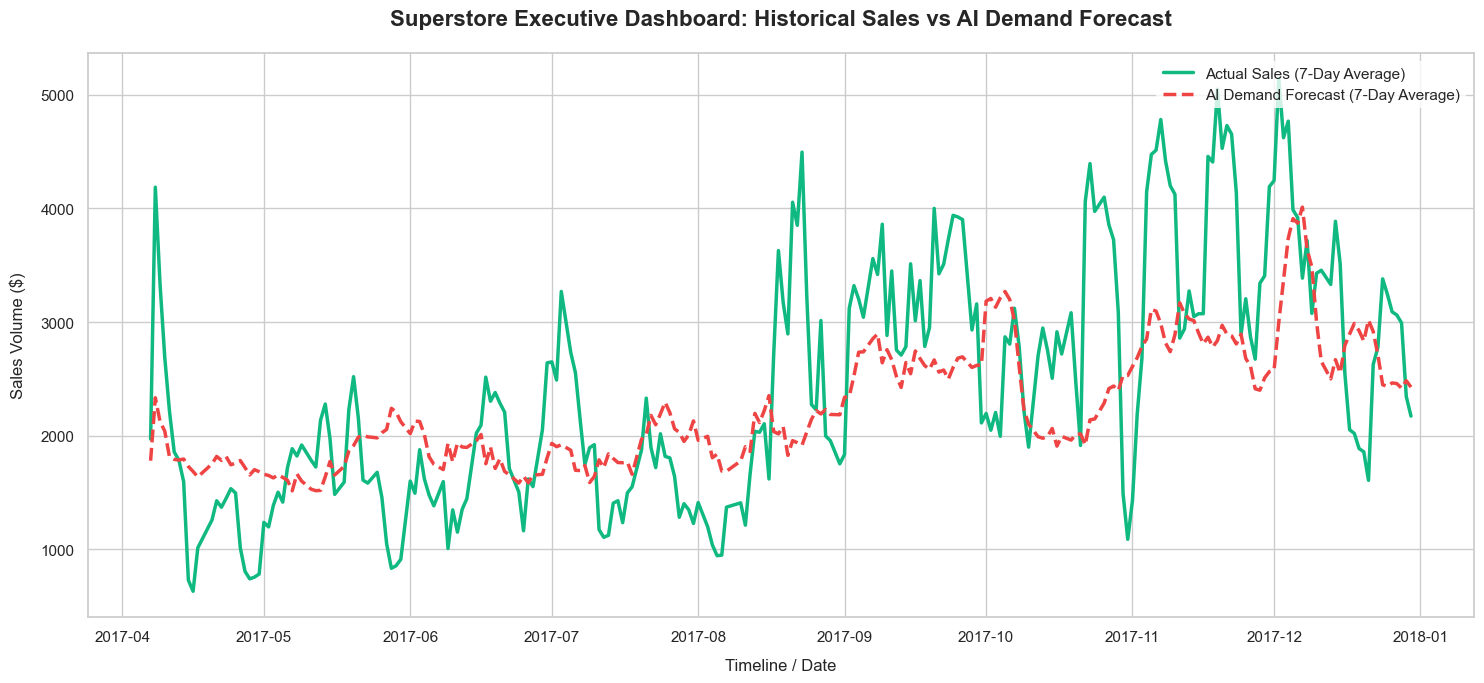

✅ Chart generated and saved to your project folder as 'superstore_sales_forecast_report.png'!


In [6]:
plt.figure(figsize=(15, 7))
sns.set_theme(style="whitegrid")

# Sort results to ensure linear timeline mapping
plot_data = results_df.sort_values('date').reset_index(drop=True)

# Apply a 7-day rolling window to smooth the visualization for stakeholders
plot_data['actual_smooth'] = plot_data['actual_sales'].rolling(window=7, min_periods=1).mean()
plot_data['pred_smooth'] = plot_data['predicted_demand'].rolling(window=7, min_periods=1).mean()

# Plot smoothed lines
plt.plot(plot_data['date'], plot_data['actual_smooth'], label='Actual Sales (7-Day Average)', color='#10b981', linewidth=2.5)
plt.plot(plot_data['date'], plot_data['pred_smooth'], label='AI Demand Forecast (7-Day Average)', color='#ef4444', linestyle='--', linewidth=2.5)

# Style choices for high-end professional reporting
plt.title('Superstore Executive Dashboard: Historical Sales vs AI Demand Forecast', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Timeline / Date', fontsize=12, labelpad=10)
plt.ylabel('Sales Volume ($)', fontsize=12, labelpad=10)
plt.legend(fontsize=11, facecolor='white', edgecolor='none', loc='upper right')

# Export the high-resolution visualization automatically for your presentation
plt.tight_layout()
plt.savefig('superstore_sales_forecast_report.png', dpi=300)
plt.show()
print("✅ Chart generated and saved to your project folder as 'superstore_sales_forecast_report.png'!")
